In [1]:
import pandas as pd
import joblib
import shap

# Reload feature-engineered data
X_train = pd.read_csv('../data/processed/X_train_fe.csv')
X_val   = pd.read_csv('../data/processed/X_val_fe.csv')

y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_val   = pd.read_csv('../data/processed/y_val.csv').squeeze()

# Reload your saved model
gb = joblib.load('../models/gradient_boosting_model.pkl')

c:\Users\sadee\Documents\Github\loan-default-risk-prediction\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
explainer = shap.Explainer(gb, X_train)
shap_values = explainer(X_val)

Background dataset has 104818 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=104818 when initializing the masker.


TypeError: Cannot cast array data from dtype('O') to dtype('float64') according to the rule 'safe'

In [3]:
X_train.dtypes

RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
TotalTimesLate                            int64
IncomePerDependent                      float64
AgeGroup_30-45                             bool
AgeGroup_45-60                             bool
AgeGroup_60+                               bool
AgeGroup_30-45.1                           bool
AgeGroup_45-60.1                           bool
AgeGroup_60+.1                             bool
dtype: object

In [4]:
X_train = X_train.astype('float64')
X_val = X_val.astype('float64')

explainer = shap.Explainer(gb, X_train)
shap_values = explainer(X_val)

Background dataset has 104818 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=104818 when initializing the masker.
100%|===================| 22402/22453 [00:31<00:00]        

ExplainerError: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. This check failed because for one of the samples the sum of the SHAP values was 1.778041, while the model output was 0.223461. If this difference is acceptable you can set check_additivity=False to disable this check.

In [5]:
shap_values = explainer(X_val, check_additivity=False)

 97%|=================== | 21709/22453 [00:30<00:01]       

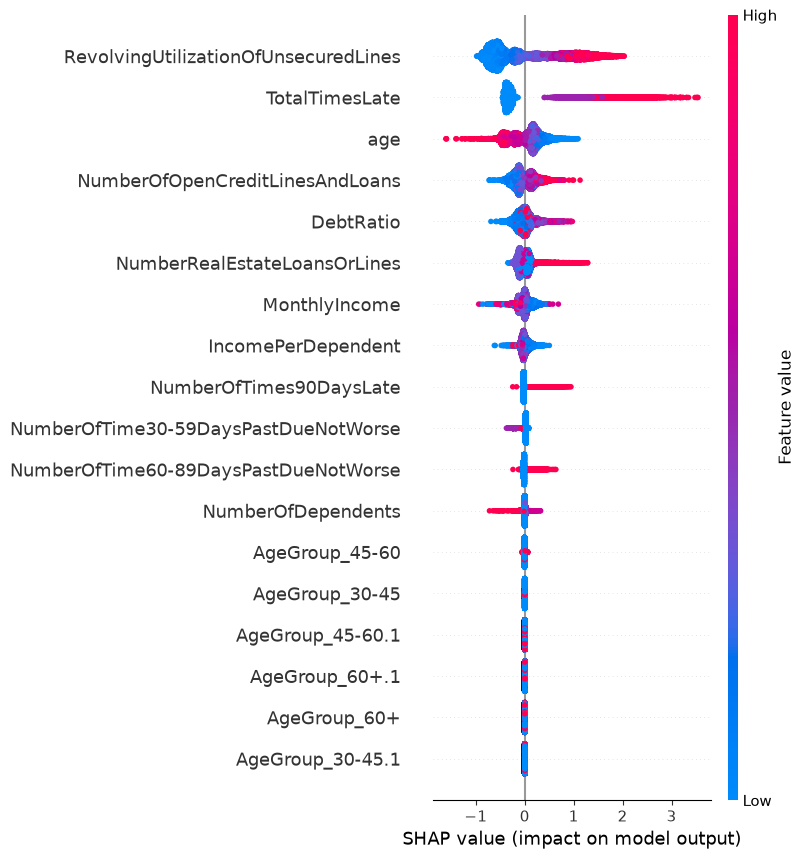

In [6]:
shap.summary_plot(shap_values, X_val)

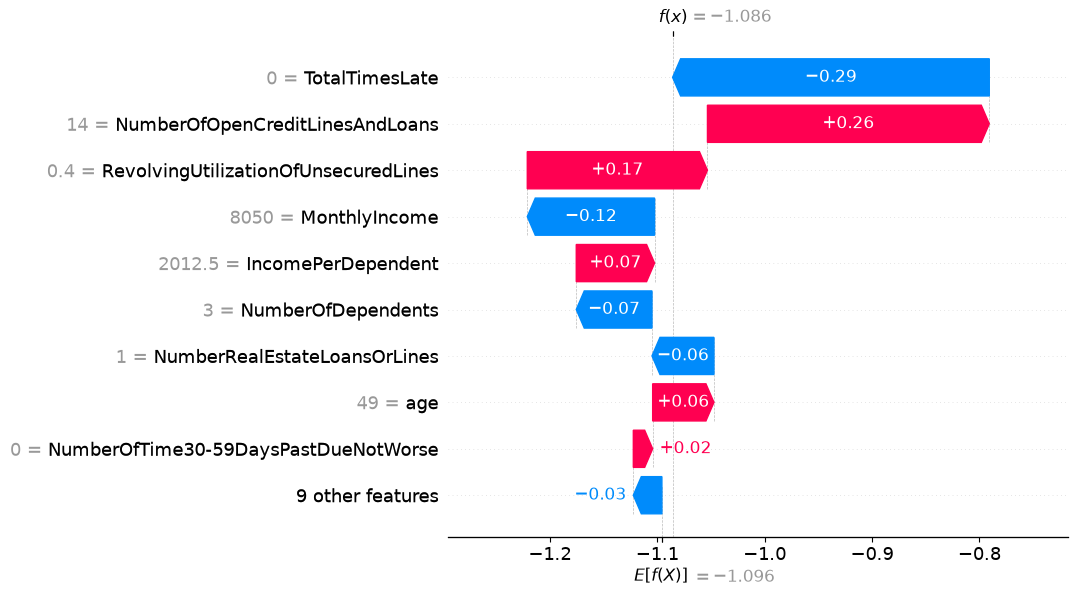

In [7]:
idx = 0
shap.plots.waterfall(shap_values[idx])